In [1]:
import fsspec
import xarray as xr
import pandas as pd 
import os
from datetime import date
import datetime
import regionmask
import geopandas as gpd
import scipy.stats as stats
from ERA5_functions import *

In [21]:
ds = xr.open_mfdataset('/data/keeling/a/rytam2/a/iema_output/variables_202602080250.nc')
t2m = ds.t2m.sel(time=ds.time.dt.year <= 2025)
skt = ds.skt.sel(time=ds.time.dt.year <= 2025)

fpath = '/data/keeling/a/rytam2/a/iema_output/arcgis_toprocess/' #for output to arcgis

In [ ]:
def to_zc(xr_ds):
    gdf = gpd.read_file('/data/keeling/a/rytam2/climstat/local/county_zc_shpfile/zc/tl_2025_us_zcta520.shp')
    il_bbox = [-91.5, 36.95, -87.5, 42.5]  # IL bounds
    zcta_il = gdf.cx[il_bbox[0]:il_bbox[2], il_bbox[1]:il_bbox[3]]  # Clip to IL
    
    ds = xr_ds.rio.write_crs('EPSG:4326')
    gdf = gdf.to_crs('EPSG:4326')

    mask = mask_geopandas(zcta_il, ds.lon, ds.lat)

    skt_mean = skt.where(mask>=0).groupby(mask).mean()
    skt_mean_gdf = skt_mean.to_dataframe().reset_index()
    result = zcta_il.merge(skt_mean_gdf, left_index=True, right_index=True) 
    
    return 

#### Zip Code

In [22]:
import xarray as xr
import geopandas as gpd
import rioxarray
from regionmask import mask_geopandas

# Load data
gdf = gpd.read_file('/data/keeling/a/rytam2/climstat/local/county_zc_shpfile/zc/tl_2025_us_zcta520.shp')
il_bbox = [-91.5, 36.95, -87.5, 42.5]  # IL bounds
zcta_il = gdf.cx[il_bbox[0]:il_bbox[2], il_bbox[1]:il_bbox[3]]  # Clip to IL
print(f"IL ZCTAs: {len(zcta_il)}")  # Should be ~1,600


# Ensure CRS match (ERA5 = 4326)
ds = skt
ds = ds.rio.write_crs('EPSG:4326')
gdf = gdf.to_crs('EPSG:4326')

# Create regionmask from shapefile
mask = mask_geopandas(zcta_il, ds.lon, ds.lat)

IL ZCTAs: 1925


In [27]:
# Apply mask and compute stats per polygon
skt_mean = skt.where(mask>=0).groupby(mask).mean()
skt_mean_gdf = skt_mean.to_dataframe().reset_index()
result = zcta_il.merge(skt_mean_gdf, left_index=True, right_index=True) 

,ZCTA5CE20,GEOID20,GEOIDFQ20,CLASSFP20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,geometry,time,mask,spatial_ref,skt
330,62914,62914,860Z200US62914,B5,G6350,S,51683018,9282310,+37.0401236,-089.2043162,"POLYGON ((-89.26415 37.08373, -89.26399 37.083...",2016-01-01 00:00:00,30859.0,0,273.509735
331,62828,62828,860Z200US62828,B5,G6350,S,214243346,282525,+38.1945325,-088.6015765,"POLYGON ((-88.70492 38.10689, -88.70489 38.108...",2016-01-01 00:00:00,30934.0,0,267.303070
332,61928,61928,860Z200US61928,B5,G6350,S,79864776,681499,+39.4559590,-088.4981966,"POLYGON ((-88.56534 39.51018, -88.5653 39.5102...",2016-01-01 00:00:00,30946.0,0,266.377716
333,62618,62618,860Z200US62618,B5,G6350,S,261102497,15276214,+40.0087310,-090.3972545,"POLYGON ((-90.53759 39.91975, -90.53722 39.920...",2016-01-01 00:00:00,30947.0,0,268.497406
334,60934,60934,860Z200US60934,B5,G6350,S,81396632,73472,+40.9570909,-088.3451035,"POLYGON ((-88.4166 40.99257, -88.41628 40.9925...",2016-01-01 00:00:00,30958.0,0,272.637054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33629,61533,61533,860Z200US61533,B5,G6350,S,105156754,2100676,+40.5863741,-089.8424993,"POLYGON ((-89.94029 40.62538, -89.93949 40.625...",2016-01-04 17:00:00,31572.0,0,274.390808
33630,61547,61547,860Z200US61547,B5,G6350,S,56931194,2103009,+40.5700081,-089.7218456,"POLYGON ((-89.79488 40.61684, -89.79434 40.616...",2016-01-04 17:00:00,32221.0,0,275.809021
33631,61020,61020,860Z200US61020,B5,G6350,S,81475979,0,+42.1103397,-089.0980881,"POLYGON ((-89.15324 42.06855, -89.15324 42.068...",2016-01-04 17:00:00,32225.0,0,276.035248
33632,60645,60645,860Z200US60645,B5,G6350,S,5765065,0,+42.0086034,-087.6945792,"POLYGON ((-87.70937 42.00101, -87.70937 42.001...",2016-01-04 17:00:00,32228.0,0,275.006775


In [38]:
result['ZCTA5CE20'].unique()#sort()

array(['62914', '62828', '61928', ..., '61020', '60645', '62951'],
      shape=(1925,), dtype=object)

In [31]:
result.groupby('ZCTA5CE20').mean('skt')

,ALAND20,AWATER20,mask,spatial_ref,skt
ZCTA5CE20,,,,,
42001,192279411.0,1717798.0,8122.0,0.0,269.151489
42003,178578559.0,5272796.0,23076.0,0.0,273.210693
42022,1273220.0,672.0,28142.0,0.0,275.299774
42024,120229349.0,11190156.0,6006.0,0.0,272.242065
42025,517227406.0,53113927.0,33388.0,0.0,275.217773
...,...,...,...,...,...
65565,714690760.0,532584.0,8119.0,0.0,271.006927
65566,29534526.0,71647.0,14127.0,0.0,267.391479
65571,481275485.0,227140.0,22001.0,0.0,280.472504


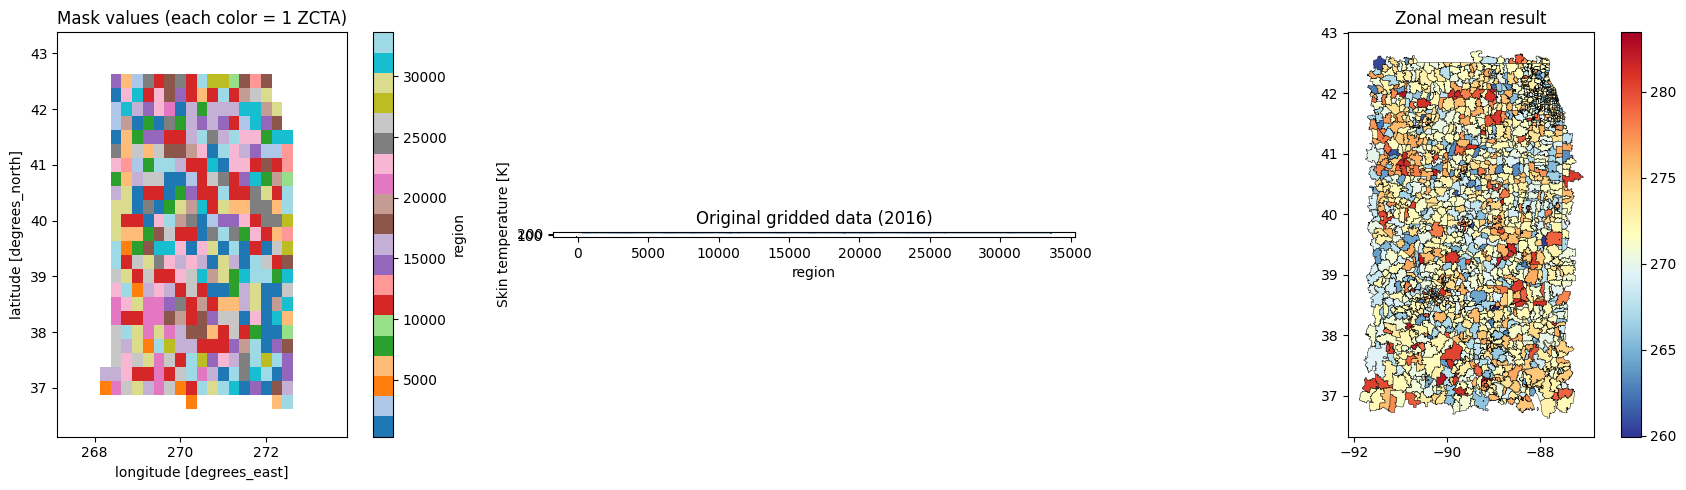

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: The mask
mask.plot(ax=axes[0], cmap='tab20')
zcta_il.boundary.plot(ax=axes[0], color='black', linewidth=0.5)
axes[0].set_title('Mask values (each color = 1 ZCTA)')

# Plot 2: Original data for one year
result.plot(ax=axes[2], legend=True, 
            cmap='RdYlBu_r', edgecolor='black', linewidth=0.3)
axes[2].set_title('Zonal mean result')

# Plot 3: Zonal statistics result
result.plot(column='skt', ax=axes[2], legend=True, 
            cmap='RdYlBu_r', edgecolor='black', linewidth=0.3)
axes[2].set_title('Zonal mean result')

plt.tight_layout()
plt.show()

#### Statistics Summary